## This notebook is to extract channel bank pixels
- as defined in section 4.2 of Varugu et al. (2025) DeltaX UAVSAR channel masks paper.

In [14]:
import os, sys, glob
import numpy as np
from mintpy.utils import ptime, readfile, writefile
import matplotlib.pyplot as plt
from skimage import measure, segmentation as seg, morphology as morph


## Read channel mask
- download data from zenodo (https://zenodo.org/records/14047957).
- make the intermittent channels to water for a binary mask

In [15]:
data_folder = '/Users/bkv3/Downloads/UAVSAR_channel_masks';
channel_mask = readfile.read(os.path.join(data_folder,'radar_coordinates/hightide_wetland_openwater_intermittentflow_mask.h5'))[0];
channel_mask[channel_mask==2]=0;

## Create connected components

In [16]:
#create connected components
cc, cc_labels = measure.label(channel_mask, connectivity=1, return_num=True)  # Create new label usign coh mask
cc = morph.remove_small_objects(cc, min_size=5000,connectivity=1)  # Remove features smaller than "min_size"
cc, cc_labels = measure.label(cc, connectivity=1, return_num=True)  # re-lable the layer without removed


## Erode the connected components
- erosion size = 10 pixels

In [17]:
# erode connected components
erosion_size =10; #set the pixels no along the channles
erosion_structure = np.ones((erosion_size, erosion_size))
eroded_cc = morph.erosion(cc, erosion_structure).astype(np.int64);


## Get channel bank pixels
- bank pixels = (connected compoents) - (eroded connected compoents)

In [18]:
channel_bank = cc - eroded_cc;

## Plot cc, eroded_cc and channel banks 
- define a subset for plotting 

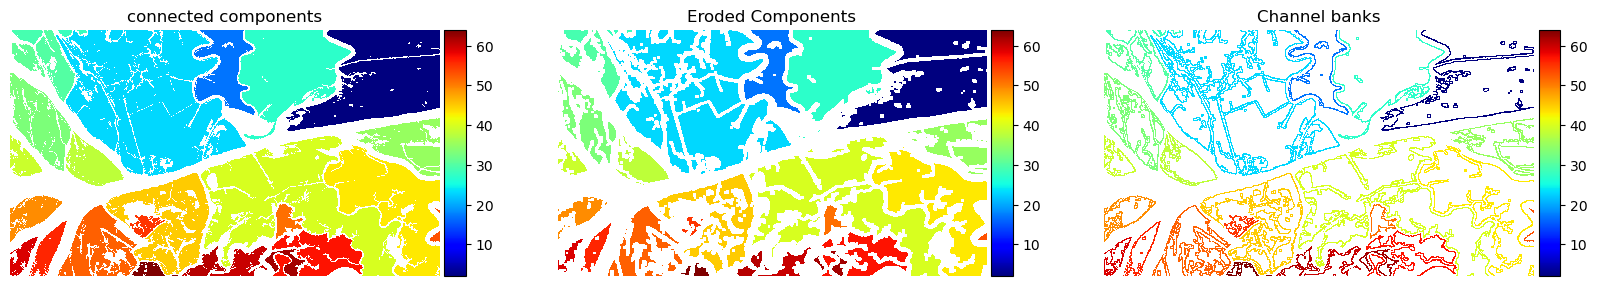

In [19]:
#%matplotlib inline
def colorbar(mappable, title=''):
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    last_axes = plt.gca()
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(mappable, cax=cax)
    cbar.ax.set_ylabel(title, rotation=270)
    plt.sca(last_axes)
    return cbar
%matplotlib inline
fig = plt.figure(figsize=(20, 5)) # New figure
ymin,ymax = 1936,2960;
xmin,xmax = 3,1789;
ax = fig.add_subplot(1,3,1) # subplot
cax=ax.imshow(np.ma.masked_where(cc[ymin:ymax,xmin:xmax]==0, cc[ymin:ymax,xmin:xmax]), cmap='jet', interpolation='nearest')
ax.set_title(r'connected components')
ax.set_axis_off()
colorbar(cax)
ax = fig.add_subplot(1,3,2) # subplot

cax=ax.imshow(np.ma.masked_where(eroded_cc[ymin:ymax,xmin:xmax]==0, eroded_cc[ymin:ymax,xmin:xmax]), cmap='jet', interpolation='nearest')
ax.set_title(r'Eroded Components')
ax.set_axis_off()
colorbar(cax)


ax = fig.add_subplot(1,3,3)

cax=ax.imshow(np.ma.masked_where(channel_bank[ymin:ymax,xmin:xmax]==0, channel_bank[ymin:ymax,xmin:xmax]), cmap='jet', interpolation='nearest')
ax.set_title(r'Channel banks')
ax.set_axis_off()
colorbar(cax);